<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/Ploynomial/car_price(LinearVIFPolynomialRFELassoRidge)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [110]:
!gdown 1qXoDeYVC4vhd7xTNwohxh9dMCjjtoHoJ

Downloading...
From: https://drive.google.com/uc?id=1qXoDeYVC4vhd7xTNwohxh9dMCjjtoHoJ
To: /content/cars24-car-price-cleaned-new.csv
100% 1.55M/1.55M [00:00<00:00, 134MB/s]


In [111]:
df1_carprice = pd.read_csv("cars24-car-price-cleaned-new.csv")

In [112]:
df1_carprice.head(2)

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.2,120000,19.7,796.0,46.3,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.5,20000,18.9,1197.0,82.0,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0


In [113]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df1_carprice, test_size=0.2, random_state=42)

In [114]:
df_train.shape

(15856, 17)

In [115]:
df_test.shape

(3964, 17)

In [116]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3964 entries, 960 to 15176
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   selling_price     3964 non-null   float64
 1   km_driven         3964 non-null   int64  
 2   mileage           3964 non-null   float64
 3   engine            3964 non-null   float64
 4   max_power         3964 non-null   float64
 5   age               3964 non-null   float64
 6   make              3964 non-null   object 
 7   model             3964 non-null   object 
 8   Individual        3964 non-null   int64  
 9   Trustmark Dealer  3964 non-null   int64  
 10  Diesel            3964 non-null   int64  
 11  Electric          3964 non-null   int64  
 12  LPG               3964 non-null   int64  
 13  Petrol            3964 non-null   int64  
 14  Manual            3964 non-null   int64  
 15  5                 3964 non-null   int64  
 16  >5                3964 non-null   int64  
dt

In [117]:
df1_carprice["make"].nunique()

41

In [118]:
df1_carprice["model"].nunique()

3233

#Perform target encoding for make and model col

In [119]:
# Make copies of x_train and x_test to avoid modifying the originals directly

categorical_features = ['make', 'model']

# Calculate the global target mean from the training data
global_mean = df_train["selling_price"].mean()

for feature in categorical_features:
    # Calculate target means for each category in the training data
    target_mean_map = df_train.groupby(feature)["selling_price"].mean()

    # Apply target encoding to x_train
    df_train[feature] = df_train[feature].map(target_mean_map)

    # Apply target encoding to x_test, filling unseen categories with the global mean
    df_test[feature] = df_test[feature].map(target_mean_map).fillna(global_mean)
    df_train_encoded = df_train.copy()
    df_test_encoded = df_test.copy()

#Transform the data

In [120]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_train_transformed = scaler.fit_transform(df_train_encoded)
df_train_transformed = pd.DataFrame(df_train_transformed, columns = df_train_encoded.columns.tolist())
df_test_transformed = pd.DataFrame(scaler.fit_transform(df_test_encoded), columns = df_test_encoded.columns.tolist())
df_test_transformed.head(2)

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.321912,0.020795,0.147104,0.219620,0.143011,0.173913,0.198613,0.177838,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.212169,0.015925,0.132625,0.225247,0.150179,0.260870,0.245607,0.218534,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


#X Y split

In [121]:
from sklearn.preprocessing import TargetEncoder
y_train = df_train_transformed["selling_price"]
x_train = df_train_transformed.drop("selling_price", axis=1)
y_test = df_test_transformed["selling_price"]
x_test = df_test_transformed.drop("selling_price", axis=1)

#Train the linear model

In [122]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [123]:
y_test_predict = model.predict(x_test)
y_train_predict= model.predict(x_train)


#Train R^2

In [124]:
model.score(x_train,y_train)

0.9469300846690971

#Test R^2

In [125]:
model.score(x_test,y_test)

0.8390879901982455

In [126]:
residual_train = y_train - y_train_predict

#Assumptions

In [127]:
##Feature Importance

In [128]:
feature_importance = pd.Series(abs(model.coef_), index=x_test.columns)
feature_importance.sort_values(ascending=False, inplace=True)

In [129]:
feature_importance

,0
model,0.861589
age,0.237195
mileage,0.233827
km_driven,0.232270
Electric,0.117955
engine,0.079190
make,0.067614
max_power,0.040113
>5,0.021211
LPG,0.014841


<Axes: title={'center': 'Feature Importance'}>

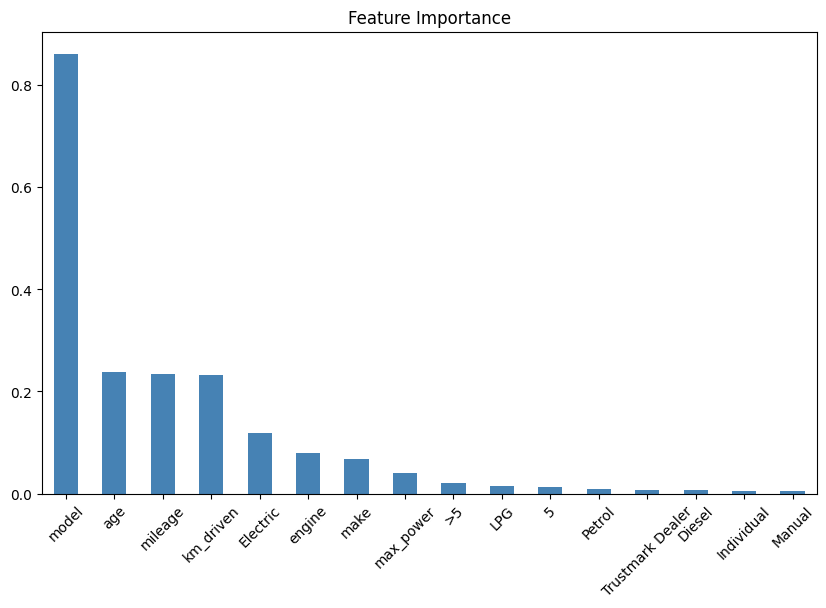

In [130]:
feature_importance.plot(kind="bar", figsize=(10,6), color='steelblue', title='Feature Importance', rot=45)


##Residual Error Distribution

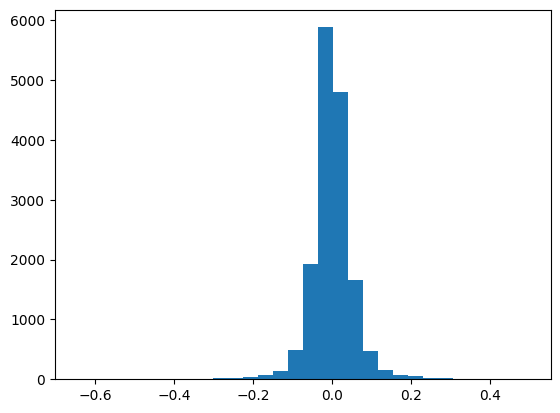

In [131]:

plt.hist(residual_train, bins=30)
plt.show()

##VIF

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["features"] = x_train.columns
vif_data

,features
0,km_driven
1,mileage
2,engine
3,max_power
4,age
5,make
6,model
7,Individual
8,Trustmark Dealer
9,Diesel


In [133]:
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif_data.sort_values(by="VIF", ascending=False, inplace=True)

In [134]:
vif_data

,features,VIF
14,5,50.955980
2,engine,50.589321
3,max_power,27.245294
9,Diesel,26.806672
12,Petrol,22.467646
1,mileage,22.432425
6,model,16.628888
5,make,12.373947
15,>5,10.883170
4,age,8.810498


In [135]:
print(f" column to be dropped {vif_data.iloc[0]["features"]}")
x_train.drop(vif_data.iloc[0]["features"], axis=1)
x_test.drop(vif_data.iloc[0]["features"], axis=1)

 column to be dropped 5


,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,>5
0,0.020795,0.147104,0.219620,0.143011,0.173913,0.198613,0.177838,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.015925,0.132625,0.225247,0.150179,0.260870,0.245607,0.218534,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.018531,0.201737,0.225247,0.167742,0.217391,0.267468,0.223589,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.007742,0.118726,0.179772,0.150000,0.217391,0.267468,0.257656,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.015530,0.140154,0.149202,0.111290,0.391304,0.204627,0.082297,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3959,0.007107,0.125483,0.179620,0.146595,0.347826,0.267468,0.132303,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3960,0.015530,0.028958,0.301445,0.416416,0.260870,0.969331,0.295337,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3961,0.012898,0.120656,0.158783,0.111111,0.521739,0.204627,0.049367,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3962,0.012898,0.107143,0.179468,0.144803,0.478261,0.204627,0.143451,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [136]:
model2 = LinearRegression()

In [137]:
model2.fit(x_train, y_train)

LinearRegression()

In [138]:
if (model2.score(x_train, y_train) - model2.score(x_test, y_test)) > 0.05:
  print(f"training R square {model2.score(x_train, y_train)}")
  print(f"testing R square {model2.score(x_test, y_test)}")
  print("model might be overfitting")

training R square 0.9469300846690971
testing R square 0.8390879901982455
model might be overfitting


##Residuals vs. Predicted Values (Train Set)

In [139]:
train_residual = y_train - y_train_predict

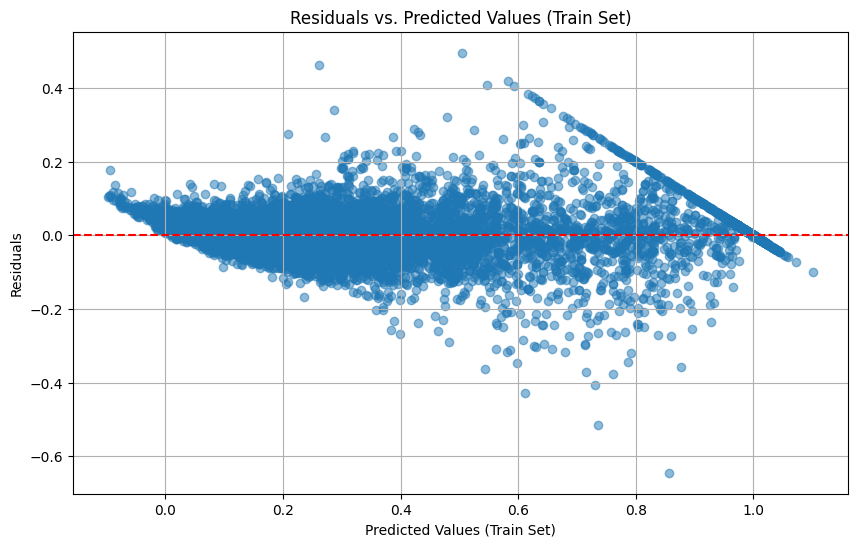

In [140]:
plt.figure(figsize=(10,6))
plt.scatter(y_train_predict,train_residual, alpha=0.5)
plt.title("Residuals vs. Predicted Values (Train Set)")
plt.xlabel("Predicted Values (Train Set)")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

##Residuals vs. Actual Values (Train Set)

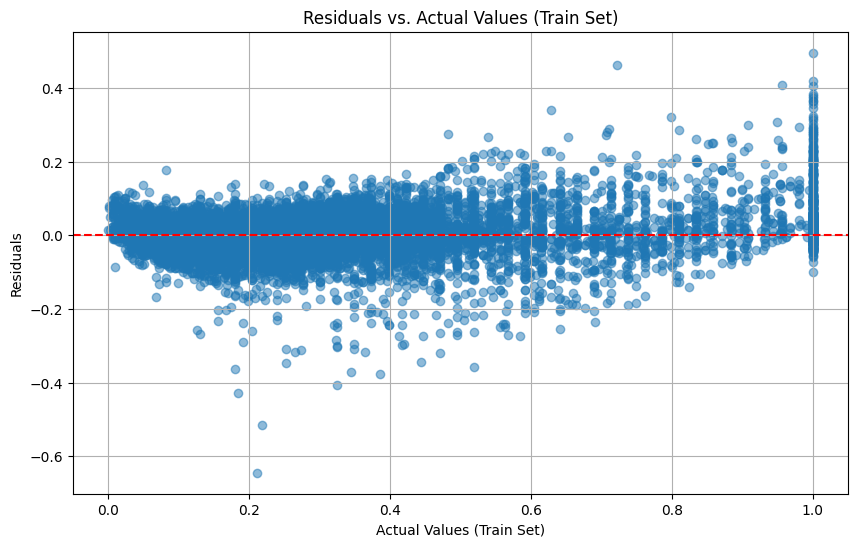

In [141]:
plt.figure(figsize=(10,6))
plt.scatter(y_train, train_residual,alpha=0.5)
plt.title("Residuals vs. Actual Values (Train Set)")
plt.xlabel("Actual Values (Train Set)")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

🔍 Observations
The residuals are not evenly scattered around the zero line.
There is a clear funnel-shaped pattern → residuals spread increases as actual values increase.
Many points at higher actual values show larger positive and negative errors.
Some noticeable outliers exist, especially on the right side.

📌 Inference
The model likely underfits the higher-value range (complex pattern not captured well).
Indicates the target may have a non-linear relationship that a linear model isn’t capturing.
Feature engineering, polynomial regression, or tree-based models might help improve performance.

##Polynomial Regression

In [142]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

In [143]:
Degrees = [1,2,3,4]
test_r2 = []
train_r2 = []
for  Degree in Degrees:
  model_degree = make_pipeline(PolynomialFeatures(degree=Degree), LinearRegression())
  model_degree.fit(x_train, y_train)
  train_r2.append(model_degree.score(x_train, y_train))
  test_r2.append(model_degree.score(x_test, y_test))
  print(f"for degree {Degree}: Train R2 --> {model_degree.score(x_train, y_train)} and test R2 -->{model_degree.score(x_test, y_test)}")

for degree 1: Train R2 --> 0.9469300846690971 and test R2 -->0.839087990198245
for degree 2: Train R2 --> 0.9540418112497379 and test R2 -->0.8765490920536406
for degree 3: Train R2 --> 0.9623660997892469 and test R2 -->-65.70167528715427
for degree 4: Train R2 --> 0.97084003096983 and test R2 -->-96791249.67413302


Oberervation: R2 for both training and testing has increased for degree 2 from dregee 1. But after that for degree 3 and 4, train R2 has increased for degree but reduced to negetive leaiding to overfit scenario. Hence the best degree to choose is 2.

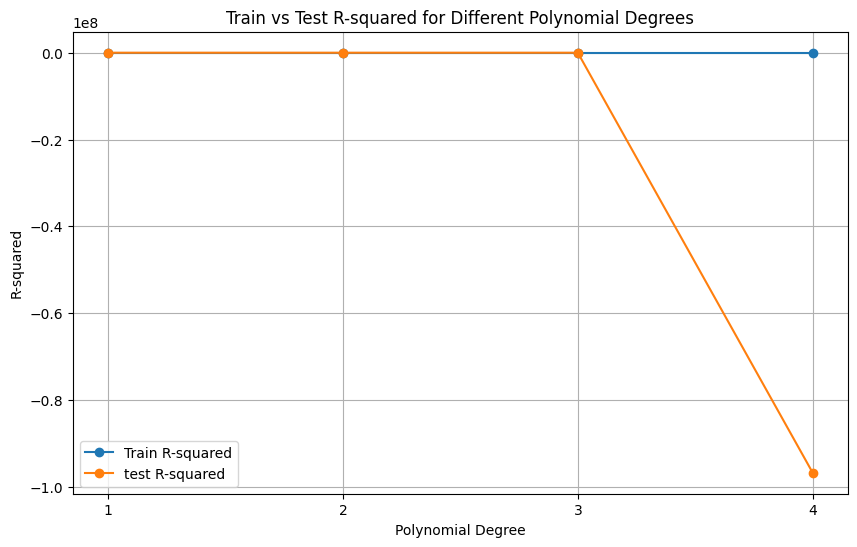

In [144]:
plt.figure(figsize=(10,6))
plt.plot(Degrees, train_r2, marker='o', label='Train R-squared')
plt.plot(Degrees, test_r2, marker='o', label='test R-squared')
plt.title('Train vs Test R-squared for Different Polynomial Degrees')
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared')
plt.xticks(Degrees)
plt.grid(True)
plt.legend()
plt.show()


##Lasso and Ridge

In [145]:
from sklearn.linear_model import Lasso, Ridge

# Define a list of alpha values to evaluate
alphas = [0.001, 0.01, 0.1, 1, 10] #lambda

print("Lasso Regression:")
print("="*30)
for alpha in alphas:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(x_train, y_train)
    train_r2_lasso = lasso_model.score(x_train, y_train)
    test_r2_lasso = lasso_model.score(x_test, y_test)
    print(f"Alpha: {alpha}, Train R-squared: {train_r2_lasso:.4f}, Test R-squared: {test_r2_lasso:.4f}")

print("\n" + "="*30 + "\n") # Separator

print("Ridge Regression:")
print("="*30)
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(x_train, y_train)
    train_r2_ridge = ridge_model.score(x_train, y_train)
    test_r2_ridge = ridge_model.score(x_test, y_test)
    print(f"Alpha: {alpha}, Train R-squared: {train_r2_ridge:.4f}, Test R-squared: {test_r2_ridge:.4f}")

Lasso Regression:
Alpha: 0.001, Train R-squared: 0.9421, Test R-squared: 0.8013
Alpha: 0.01, Train R-squared: 0.9029, Test R-squared: 0.7671
Alpha: 0.1, Train R-squared: 0.0000, Test R-squared: -0.0000
Alpha: 1, Train R-squared: 0.0000, Test R-squared: -0.0000
Alpha: 10, Train R-squared: 0.0000, Test R-squared: -0.0000


Ridge Regression:
Alpha: 0.001, Train R-squared: 0.9469, Test R-squared: 0.8391
Alpha: 0.01, Train R-squared: 0.9469, Test R-squared: 0.8391
Alpha: 0.1, Train R-squared: 0.9469, Test R-squared: 0.8392
Alpha: 1, Train R-squared: 0.9469, Test R-squared: 0.8398
Alpha: 10, Train R-squared: 0.9464, Test R-squared: 0.8452


Observation: In general if R2 of train is very high as compare to R2 of test example 66% and 13%. This is an overfit scenario. When lasso or ridge is  applied on such a model. Test R2 and train R2 come very close. here in this example for Lasso train R2 decreased to match test R2 but test R2 did not improve. this means for this data polynomial regression will not work.
For alpha 0.1 and above R2 becomes zero which underfit scenario.

For ridge, even for higher values of alpha R2 did not become zero which means m values did not become zero. Also the impovement is very small. Generally, Lasso or Ridge will show their effect when in overfit scenario the difference between train and test R2 is big.



Removing features using RFE


In [146]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model as the estimator
estimator = LinearRegression()

# Create the RFE model and select half of the features
num_features_to_select = x_train.shape[1] // 2
rfe_selector = RFE(estimator=estimator, n_features_to_select=num_features_to_select, step=1)

# Fit the RFE model to the training data
rfe_selector.fit(x_train, y_train)

# Get the selected features and their ranking
selected_features_rfe = x_train.columns[rfe_selector.support_]
feature_ranking_rfe = pd.Series(rfe_selector.ranking_, index=x_train.columns)

print("Features selected by RFE:")
print(selected_features_rfe)

print("\nFeature ranking by RFE (1 indicates selected features):")
print(feature_ranking_rfe.sort_values())

Features selected by RFE:
Index(['km_driven', 'mileage', 'engine', 'max_power', 'age', 'make', 'model',
       'Electric'],
      dtype='object')

Feature ranking by RFE (1 indicates selected features):
km_driven           1
mileage             1
engine              1
max_power           1
age                 1
make                1
model               1
Electric            1
Petrol              2
>5                  3
5                   4
LPG                 5
Trustmark Dealer    6
Individual          7
Diesel              8
Manual              9
dtype: int64


Training a Linear regression molel using selected features from RFE

In [147]:
from sklearn.linear_model import LinearRegression

# Create a new Linear Regression model
model_rfe = LinearRegression()

# Train the model using only the selected features from RFE
X_train_rfe = x_train[selected_features_rfe]
X_test_rfe = x_test[selected_features_rfe]

model_rfe.fit(X_train_rfe, y_train)

# Calculate R-squared scores
train_r2_rfe = model_rfe.score(X_train_rfe, y_train)
test_r2_rfe = model_rfe.score(X_test_rfe, y_test)

print(f"Train R-squared with RFE selected features: {train_r2_rfe:.4f}")
print(f"Test R-squared with RFE selected features: {test_r2_rfe:.4f}")

Train R-squared with RFE selected features: 0.9462
Test R-squared with RFE selected features: 0.8352


Model still overfits

In [148]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Create a polynomial regression pipeline with degree 2
poly_model_rfe = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Fit the model to the RFE-selected training data
poly_model_rfe.fit(X_train_rfe, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_poly_rfe = poly_model_rfe.score(X_train_rfe, y_train)
test_r2_poly_rfe = poly_model_rfe.score(X_test_rfe, y_test)

print(f"Polynomial Regression (Degree 2) with RFE-selected features:")
print(f"  Train R-squared: {train_r2_poly_rfe:.4f}")
print(f"  Test R-squared: {test_r2_poly_rfe:.4f}")

Polynomial Regression (Degree 2) with RFE-selected features:
  Train R-squared: 0.9511
  Test R-squared: 0.8661


In [149]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Create a polynomial regression pipeline with degree 2
poly_model_rfe = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# Fit the model to the RFE-selected training data
poly_model_rfe.fit(X_train_rfe, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_poly_rfe = poly_model_rfe.score(X_train_rfe, y_train)
test_r2_poly_rfe = poly_model_rfe.score(X_test_rfe, y_test)

print(f"Polynomial Regression (Degree 3) with RFE-selected features:")
print(f"  Train R-squared: {train_r2_poly_rfe:.4f}")
print(f"  Test R-squared: {test_r2_poly_rfe:.4f}")

Polynomial Regression (Degree 3) with RFE-selected features:
  Train R-squared: 0.9563
  Test R-squared: 0.4465


In [150]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Create a polynomial regression pipeline with degree 2
poly_model_rfe = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())

# Fit the model to the RFE-selected training data
poly_model_rfe.fit(X_train_rfe, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_poly_rfe = poly_model_rfe.score(X_train_rfe, y_train)
test_r2_poly_rfe = poly_model_rfe.score(X_test_rfe, y_test)

print(f"Polynomial Regression (Degree 4) with RFE-selected features:")
print(f"  Train R-squared: {train_r2_poly_rfe:.4f}")
print(f"  Test R-squared: {test_r2_poly_rfe:.4f}")

Polynomial Regression (Degree 4) with RFE-selected features:
  Train R-squared: 0.9618
  Test R-squared: -68.3779


In [151]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Initialize PolynomialFeatures with degree 2
poly = PolynomialFeatures(degree=2)

# Transform the RFE-selected training and testing data
X_train_poly = poly.fit_transform(X_train_rfe)
X_test_poly = poly.transform(X_test_rfe)

# Create and fit a Linear Regression model on the transformed data
model_poly_no_pipeline = LinearRegression()
model_poly_no_pipeline.fit(X_train_poly, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_poly_no_pipeline = model_poly_no_pipeline.score(X_train_poly, y_train)
test_r2_poly_no_pipeline = model_poly_no_pipeline.score(X_test_poly, y_test)

print(f"Polynomial Regression (Degree 2) without Pipeline using RFE-selected features:")
print(f"  Train R-squared: {train_r2_poly_no_pipeline:.4f}")
print(f"  Test R-squared: {test_r2_poly_no_pipeline:.4f}")

Polynomial Regression (Degree 2) without Pipeline using RFE-selected features:
  Train R-squared: 0.9511
  Test R-squared: 0.8661


In [152]:
# Identify columns to drop based on VIF > 10, excluding 'model'
columns_to_drop = vif_data[ (vif_data['VIF'] > 10) & (vif_data['features'] != 'model') ]['features'].tolist()

print(f"Columns to be dropped: {columns_to_drop}")

# Drop identified columns from x_train and x_test
x_train_reduced = x_train.drop(columns=columns_to_drop, axis=1)
x_test_reduced = x_test.drop(columns=columns_to_drop, axis=1)

print(f"Shape of x_train after dropping columns: {x_train_reduced.shape}")
print(f"Shape of x_test after dropping columns: {x_test_reduced.shape}")

Columns to be dropped: ['5', 'engine', 'max_power', 'Diesel', 'Petrol', 'mileage', 'make', '>5']
Shape of x_train after dropping columns: (15856, 8)
Shape of x_test after dropping columns: (3964, 8)


In [153]:
from sklearn.linear_model import LinearRegression

# Initialize a new Linear Regression model
model_reduced = LinearRegression()

# Fit the model to the reduced training data
model_reduced.fit(x_train_reduced, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_reduced = model_reduced.score(x_train_reduced, y_train)
test_r2_reduced = model_reduced.score(x_test_reduced, y_test)

print(f"Linear Regression with VIF-reduced features:")
print(f"  Train R-squared: {train_r2_reduced:.4f}")
print(f"  Test R-squared: {test_r2_reduced:.4f}")

Linear Regression with VIF-reduced features:
  Train R-squared: 0.9439
  Test R-squared: 0.8060


In [154]:
# Drop the 'model' column from the already reduced dataframes
x_train_final = x_train_reduced.drop(columns=['model'], axis=1)
x_test_final = x_test_reduced.drop(columns=['model'], axis=1)

print(f"Shape of x_train after dropping 'model': {x_train_final.shape}")
print(f"Shape of x_test after dropping 'model': {x_test_final.shape}")

# Initialize a new Linear Regression model
model_final = LinearRegression()

# Fit the model to the final reduced training data
model_final.fit(x_train_final, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_final = model_final.score(x_train_final, y_train)
test_r2_final = model_final.score(x_test_final, y_test)

print(f"\nLinear Regression after dropping 'model' column:")
print(f"  Train R-squared: {train_r2_final:.4f}")
print(f"  Test R-squared: {test_r2_final:.4f}")

Shape of x_train after dropping 'model': (15856, 7)
Shape of x_test after dropping 'model': (3964, 7)

Linear Regression after dropping 'model' column:
  Train R-squared: 0.4618
  Test R-squared: 0.3826


After dropping the 'model' column, the linear regression model resulted in a Train R-squared of 0.4618 and a Test R-squared of 0.3826. This is a significant decrease compared to the previous models. It indicates that the 'model' column, even with its potential multicollinearity issues, was a very strong predictor of the selling_price. Removing it drastically reduced the model's ability to explain the variance in the car prices, leading to a much weaker model.

In [155]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Create a polynomial regression pipeline with degree 2
poly_model_reduced = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Fit the model to the reduced training data
poly_model_reduced.fit(x_train_reduced, y_train)

# Calculate R-squared scores for training and testing sets
train_r2_poly_reduced = poly_model_reduced.score(x_train_reduced, y_train)
test_r2_poly_reduced = poly_model_reduced.score(x_test_reduced, y_test)

print(f"Polynomial Regression (Degree 2) with VIF-reduced features:")
print(f"  Train R-squared: {train_r2_poly_reduced:.4f}")
print(f"  Test R-squared: {test_r2_poly_reduced:.4f}")

Polynomial Regression (Degree 2) with VIF-reduced features:
  Train R-squared: 0.9466
  Test R-squared: 0.8083


Comparing this to the previous linear model with VIF-reduced features (Train R-squared: 0.9439, Test R-squared: 0.8060), we see a minor improvement in both training and testing R-squared scores with the introduction of polynomial features. This suggests that some non-linear relationships might be present, and the degree 2 polynomial terms help capture them slightly better.

However, when compared to the polynomial model of degree 2 that used RFE-selected features (Train R-squared: 0.9511, Test R-squared: 0.8661), this VIF-reduced set performs worse on the test set. This indicates that while removing high VIF features helped with multicollinearity, some of the dropped features were important for the model's overall predictive power, especially when interacting with other features in a polynomial manner. The RFE-selected feature set appears to have retained more predictive information, leading to a better generalized model.